# Algoritmos de Inteligência Artificial Bioinspirados - Otimização Por Colônia de Formigas - 4 vértices

Para implementar o algoritmo de otimização por colônia de formigas no grafo seguinte, primeiro precisamos entender a estrutura do grafo e como as formigas se movem através dele.

Este é um grafo ponderado direcionado, onde os nós representam locais e as arestas representam caminhos entre esses locais. Cada aresta tem um peso associado, que pode representar a distância para o problema em questão.

As formigas, ao percorrerem o grafo, depositam feromônio nas arestas percorridas, seguindo uma heurística que baseada na distância. O feromônio depositado influencia as decisões de outras formigas, criando um feedback positivo que tende a reforçar os caminhos mais promissores.

A representação utilizada segue o seguinte padrão:

`[aresta, lista de adjacência, peso da aresta, feromônio]`

Representaremos as arestas de um grafo arbitrário da seguinte forma:

In [ ]:
import random

ab = ['AB',['BC','BD'],8,1]
ac = ['AC',['BC','BD'],14,1]
ad = ['AD',[],22,1]
bc = ['BC',['CD'],9,1]
cb = ['CB',['BD'],9,1]
bd = ['BD',[],8,1]
cd = ['CD',[],10,1]

arests = [ab,ac,ad,bc,cb,bd,cd]

In [ ]:
cd[2]
ac[1]

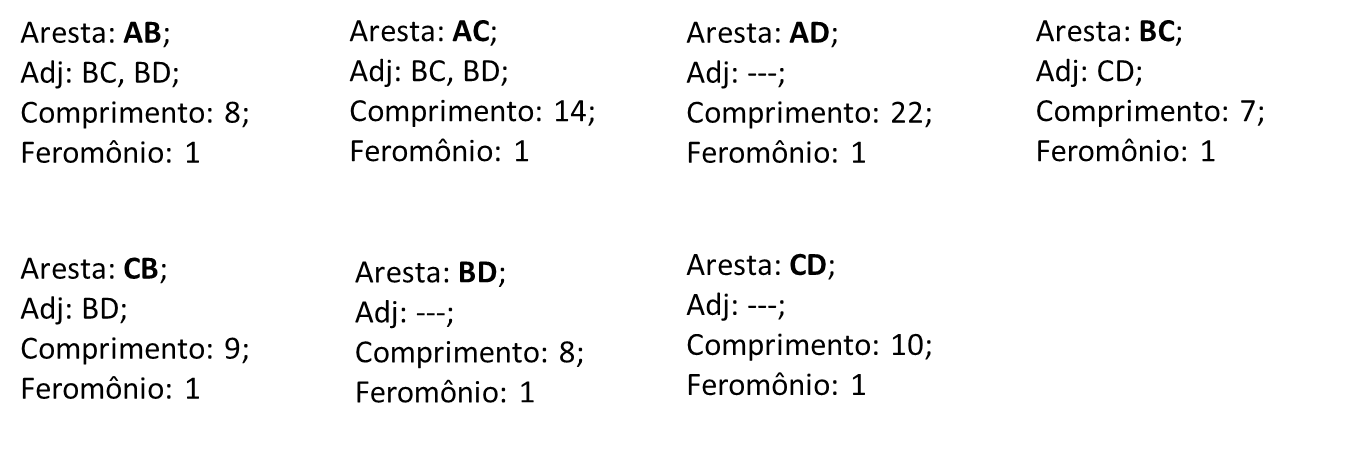

Função de probabilidade de escolha de aresta adjacente

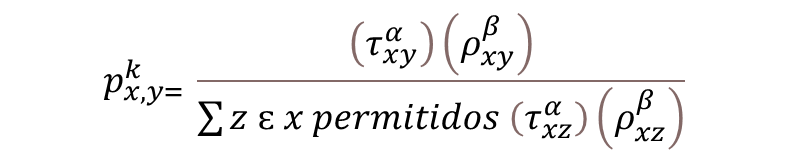

A seguir termos a função denominada probabs, que recebe como entrada adja, que representa uma lista de nós adjacentes a um nó específico no grafo. A função calcula as probabilidades normalizadas para que uma formiga escolha cada um desses nós adjacentes, com base nas distâncias e nos feromônios das arestas que conectam o nó atual aos nós adjacentes. Isso é fundamental para o movimento das formigas dentro do algoritmo de otimização por colônia de formigas, ajudando as formigas a escolherem caminhos mais promissores durante sua exploração do grafo.

Aqui está uma explicação passo a passo do que a função faz:

* Inicialização das Listas: Inicialmente, duas listas vazias são criadas: dists para armazenar as distâncias das arestas adjacentes e fer para armazenar os feromônios associados a essas arestas.
* Preenchimento das Listas: A função itera sobre a lista adja, que contém os nós adjacentes ao nó atual. Para cada nó adjacente i, a função itera sobre todas as arestas em `arests`. Se o primeiro elemento da aresta j for igual ao nó adjacente i, a distância (j[2]) e o feromônio (j[3]) dessa aresta são adicionados às listas dists e fer, respectivamente.
* Cálculo das Atratividades: Em seguida, a função calcula a "atratividade" de cada nó adjacente. Isso é feito multiplicando o feromônio da aresta correspondente pelo inverso da distância dessa aresta. Essa medida é uma heurística que combina o feromônio depositado na aresta e a distância física entre os nós.
* Normalização das Atratividades: As atratividades calculadas são normalizadas, dividindo cada uma pela soma de todas as atratividades. Isso garante que as probabilidades calculadas estejam na faixa de 0 a 1 e somem 1, tornando-as probabilidades válidas.
* Retorno das Probabilidades Normalizadas: As probabilidades normalizadas são retornadas como resultado da função.

In [ ]:
def probabs(adja):
  # Inicializar listas para armazenar distâncias e feromônios das arestas adjacentes
  dists = []
  fer = []

  # Iterar sobre os nós adjacentes fornecidos
  for i in adja:
    # Iterar sobre todas as arestas no grafo
    for j in arests:
      # Verificar se a aresta atual conecta ao nó adjacente atual
      if j[0] == i:
        # Adicionar a distância e o feromônio da aresta às listas correspondentes
        dists.append(j[2])
        fer.append(j[3])

  # Calcular as atratividades de cada nó adjacente
  atratividades = []
  cont = 0
  while cont < len(adja):
    # Atratividade é calculada multiplicando o feromônio pelo inverso da distância
    atract = fer[cont] * (1 / dists[cont])
    atratividades.append(atract)
    cont += 1

  # Calcular a soma das atratividades
  soma = sum(atratividades)

  # Normalizar as atratividades para obter probabilidades
  probs = []
  for i in atratividades:
    # A probabilidade de escolha de cada nó é sua atratividade dividida pela soma total das atratividades
    prob = (i / soma)
    probs.append(prob)

  # Retornar as probabilidades normalizadas
  return probs

Observe que, inicialmente, a aresta com comprimento menor terá a maior probabilidade de ser escolhida.

In [ ]:
probabs(['AB','AC','AD'])

[0.5167785234899329, 0.2953020134228188, 0.18791946308724833]

## Escolha de aresta adjacente

A escolha será dada utilizando o método da roleta de seleção:

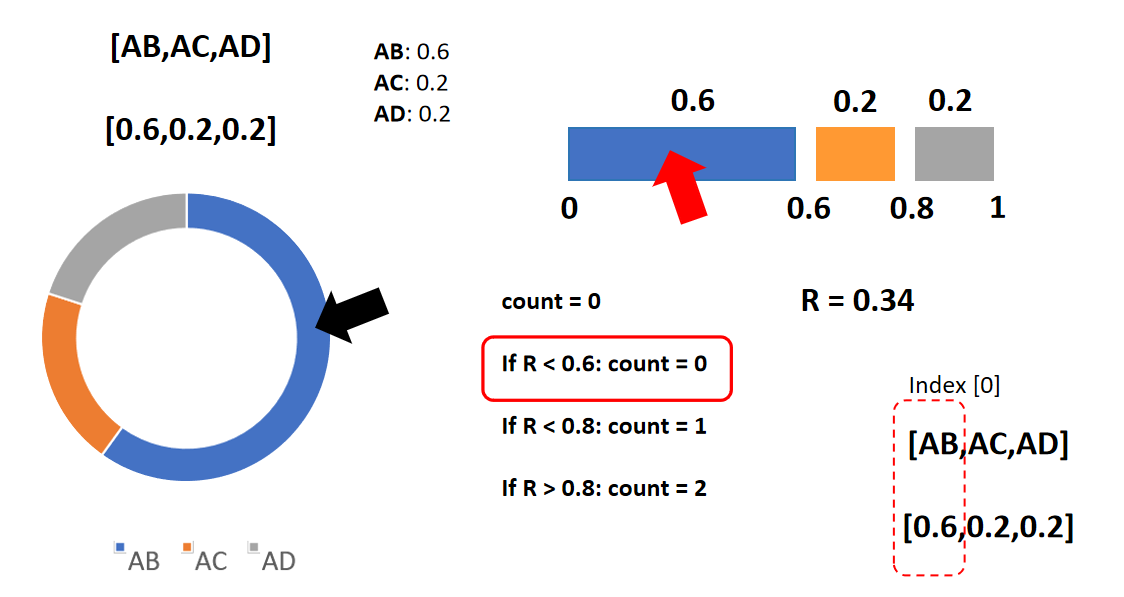

Essa função, chamada `escolhaAresta`, desempenha um papel crucial no algoritmo de otimização por colônia de formigas, pois é responsável por escolher uma aresta para a formiga seguir com base nas probabilidades calculadas pela função probabs.

Aqui está uma explicação passo a passo do que a função faz:

* Cálculo das Probabilidades: A função chama a função probabs para calcular as probabilidades de escolha de cada nó adjacente à formiga atual.
* Cálculo dos Limites de Probabilidade: Em seguida, a função itera sobre as probabilidades calculadas. Para cada probabilidade, ela calcula um limite superior acumulativo. Esses limites são armazenados na lista limiares. Isso é feito para que a seleção aleatória da próxima aresta seja baseada na probabilidade acumulada.
* Seleção Aleatória da Aresta: A função gera um número aleatório r entre 0 e 1 usando random.random(). Em seguida, itera sobre os limites de probabilidade acumulados. Quando o número aleatório r é maior que um determinado limite, significa que a formiga escolheu a aresta associada a esse limite. O índice do limite escolhido é então usado para selecionar o nó adjacente correspondente na lista adjs.
* Retorno do Nó Adjacente Selecionado: O nó adjacente escolhido é retornado como a próxima aresta que a formiga seguirá.

In [ ]:
def escolhaAresta(adjs):
  # Calcular as probabilidades de escolha de cada nó adjacente
  probab = probabs(adjs)

  # Inicializar lista para armazenar os limites de probabilidade acumulados
  limiares = []

  # Inicializar variável para armazenar a soma das probabilidades
  soma = 0

  # Calcular os limites de probabilidade acumulados
  for i in probab:
    # Adicionar a probabilidade atual à soma acumulada
    soma += i
    # Adicionar o limite de probabilidade acumulado à lista de limiares
    limiares.append(soma)

  # Gerar um número aleatório entre 0 e 1
  r = random.random()

  # Inicializar contador para encontrar o índice da próxima aresta selecionada
  cont = 0

  # Iterar sobre os limites de probabilidade acumulados
  for i in limiares:
    # Verificar se o número aleatório é maior que o limite de probabilidade atual
    if r > i:
      # Se for, incrementar o contador para indicar a próxima aresta
      cont += 1

  # Retornar o nó adjacente correspondente ao índice encontrado
  return adjs[cont]

In [ ]:
probabs(['AB','AC','AD'])

[0.5167785234899329, 0.2953020134228188, 0.18791946308724833]

In [ ]:
escolhaAresta(['AB','AC','AD'])

'AB'

## Função formiga/caminho/solução

Essa função formiga é responsável por simular o movimento de uma formiga dentro do grafo, gerando um caminho possível a partir de um nó inicial.

Aqui está uma explicação passo a passo do que a função faz:

* Inicialização do Caminho: A função cria uma lista vazia chamada caminho para armazenar os nós visitados pela formiga.
* Escolha da Aresta Inicial: A função seleciona aleatoriamente uma aresta inicial a partir de uma lista de nós adjacentes fornecidos ('AB', 'AC', 'AD'). Este nó inicial é adicionado ao caminho da formiga.
* Verificação do Destino Final: A função verifica se o último nó do caminho é o destino final ('D'). Se for, o caminho completo é retornado.
* Movimento da Formiga: Se o destino final ainda não foi alcançado, a função entra em um loop infinito. Para cada iteração do loop, a função itera sobre todas as arestas no grafo (arests). Se a origem da aresta atual corresponder ao último nó do caminho da formiga, isso significa que a formiga pode se mover para um nó adjacente. A função então escolhe aleatoriamente uma aresta adjacente usando a função escolhaAresta e adiciona o nó adjacente selecionado ao caminho da formiga.
* Retorno do Caminho: Quando a formiga alcança o destino final ou não consegue mais se mover para nenhum nó adjacente (porque todos os nós adjacentes já foram visitados), o caminho completo é retornado.

In [ ]:
def formiga():  # Função que simula o movimento de uma formiga para gerar um caminho possível
  caminho = []  # Inicializa uma lista para armazenar o caminho percorrido pela formiga

  # Escolha da aresta inicial
  inicial = escolhaAresta(['AB', 'AC', 'AD'])  # Escolhe aleatoriamente uma aresta inicial entre os nós 'AB', 'AC' e 'AD'
  caminho.append(inicial)  # Adiciona o nó inicial ao caminho da formiga

  # Verifica se o destino final foi alcançado
  if 'D' in caminho[-1]:  # Se o último nó do caminho for 'D', retorna o caminho completo
    return caminho
  else:
    while True:  # Loop infinito para o movimento da formiga
      for i in arests:  # Itera sobre todas as arestas no grafo
        if caminho[-1] == i[0]:  # Verifica se o último nó do caminho é a origem da aresta atual
          adj = i[1]  # Obtém os nós adjacentes ao último nó do caminho
          if len(adj) == 0:  # Se não houver nós adjacentes, termina o loop
            break
          else:
            adj_random = escolhaAresta(adj)  # Escolhe aleatoriamente uma aresta adjacente
            caminho.append(adj_random)  # Adiciona o nó adjacente selecionado ao caminho da formiga
      return caminho  # Retorna o caminho completo

In [ ]:
formiga()

['AB', 'BD']

### Comprimento de cada caminho/solução

A função comprimento calcula o comprimento total de um caminho percorrido por uma formiga. Ela recebe como entrada o caminho da formiga (uma lista de nós visitados) e utiliza as informações das arestas do grafo para calcular o comprimento total desse caminho.

Aqui está uma explicação passo a passo do que a função faz:

* Inicialização da Soma: A função inicializa uma variável soma com o valor zero. Esta variável será usada para acumular o comprimento total do caminho.
* Iteração sobre o Caminho da Formiga: A função itera sobre cada nó no caminho da formiga, utilizando um loop for com a variável i.
* Iteração sobre as Arestas: Para cada nó i no caminho da formiga, a função itera sobre todas as arestas no grafo (arests), utilizando um loop for com a variável j.
* Verificação da Origem da Aresta: Para cada aresta j, a função verifica se o nó i corresponde à origem da aresta j (ou seja, se a formiga passou por essa aresta).
* Acumulação do Comprimento: Se o nó i corresponder à origem da aresta j, a função adiciona o comprimento da aresta (j[2]) à soma total.
* Retorno do Comprimento Total: Após iterar sobre todos os nós no caminho da formiga e todas as arestas no grafo, a função retorna o valor acumulado na variável soma, que representa o comprimento total do caminho percorrido pela formiga.

In [ ]:
def comprimento(formiga):
  soma = 0  # Inicializa uma variável para armazenar o comprimento total do caminho
  for i in formiga:  # Itera sobre cada nó no caminho da formiga
    for j in arests:  # Itera sobre todas as arestas no grafo
      if i == j[0]:  # Verifica se o nó atual do caminho corresponde à origem da aresta atual
        soma += j[2]  # Se corresponder, adiciona o comprimento da aresta à soma total
  return soma  # Retorna o comprimento total do caminho percorrido pela formiga

In [ ]:
comprimento(['AC','CD'])

24

Atualização dos níveis de feromônio: evaporação e adição

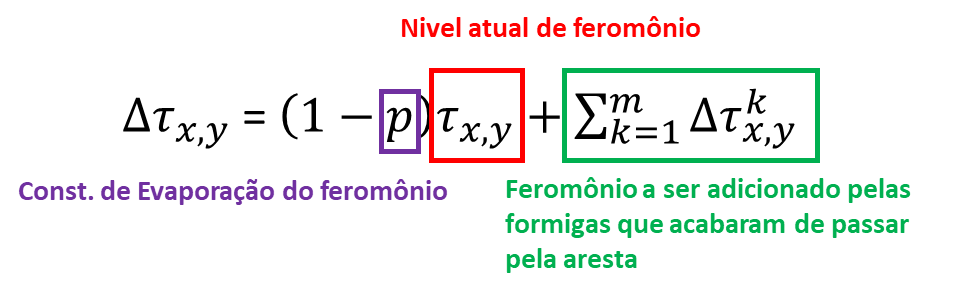

Essas duas funções estão relacionadas à atualização do feromônio nas arestas do grafo após a conclusão de uma iteração do algoritmo de colônia de formigas.

* Função de Evaporação do Feromônio (evaporacao):
    * Esta função recebe um parâmetro evap que representa a taxa de evaporação do feromônio.
    * Ela itera sobre todas as arestas no grafo (arests).
    * Para cada aresta, o valor do feromônio (i[3]) é multiplicado pelo complemento da taxa de evaporação (1 - evap). Isso simula a evaporação do feromônio ao longo do tempo, reduzindo gradualmente a quantidade de feromônio depositada em cada aresta.
* Função de Adição do Feromônio (atualiza_ferom):
    * Esta função recebe uma lista de formigas (formigas), onde cada formiga é representada por uma lista de nós visitados.
    * Para cada formiga na lista formigas, a função calcula a quantidade de feromônio a ser depositada em cada aresta com base no inverso do comprimento do caminho percorrido pela formiga.
    * Em seguida, a função itera sobre cada nó no caminho da formiga (i), e para cada nó, ela itera sobre todas as arestas no grafo (k).
    * Se o nó atual (j) corresponder à origem da aresta atual (k[0]), a quantidade de feromônio calculada é adicionada ao feromônio existente naquela aresta (k[3]).

Essencialmente, estas funções trabalham juntas para realizar a evaporação do feromônio ao longo do tempo e a adição de feromônio com base nas soluções encontradas pelas formigas em cada iteração. Isso ajuda a equilibrar a exploração e a exploração local no algoritmo de colônia de formigas, incentivando a convergência para soluções de alta qualidade.

In [ ]:
# Função para realizar a evaporação do feromônio nas arestas do grafo
def evaporacao(evap):
  for i in arests:  # Itera sobre todas as arestas no grafo
    i[3] = i[3] * (1 - evap)  # Reduz o valor do feromônio na aresta multiplicando-o pela taxa de evaporação

# Função para adicionar feromônio nas arestas com base nos caminhos percorridos pelas formigas
def atualiza_ferom(formigas):
  for i in formigas:  # Itera sobre todas as formigas
    ferom = 1 / (comprimento(i))  # Calcula a quantidade de feromônio a ser depositada com base no inverso do comprimento do caminho da formiga
    for j in i:  # Itera sobre todos os nós no caminho da formiga
      for k in arests:  # Itera sobre todas as arestas no grafo
        if k[0] == j:  # Verifica se a origem da aresta é igual ao nó atual do caminho da formiga
          k[3] = k[3] + ferom  # Adiciona a quantidade de feromônio calculada à aresta

In [ ]:
for i in arests:
  print(i)

['AB', ['BC', 'BD'], 8, 1]
['AC', ['BC', 'BD'], 14, 1]
['AD', [], 22, 1]
['BC', ['CD'], 9, 1]
['CB', ['BD'], 9, 1]
['BD', [], 8, 1]
['CD', [], 10, 1]


In [ ]:
evaporacao(0.3)

for i in arests:
  print(i)

['AB', ['BC', 'BD'], 8, 0.7]
['AC', ['BC', 'BD'], 14, 0.7]
['AD', [], 22, 0.7]
['BC', ['CD'], 9, 0.7]
['CB', ['BD'], 9, 0.7]
['BD', [], 8, 0.7]
['CD', [], 10, 0.7]


In [ ]:
formigas = [['AB','BD'],['AD']]
atualiza_ferom(formigas)

for i in arests:
  print(i)

['AB', ['BC', 'BD'], 8, 0.7625]
['AC', ['BC', 'BD'], 14, 0.7]
['AD', [], 22, 0.7454545454545454]
['BC', ['CD'], 9, 0.7]
['CB', ['BD'], 9, 0.7]
['BD', [], 8, 0.7625]
['CD', [], 10, 0.7]


### Execução do algoritmo

O seguinte trecho de código representa a execução do algoritmo de otimização por colônia de formigas para resolver um problema específico.

* Laço de Iteração Principal:
    * Um laço for é utilizado para realizar 30 iterações do algoritmo. Isso significa que o processo de evaporação, geração de formigas e atualização do feromônio será repetido 30 vezes.
* Evaporação do Feromônio:
    * Dentro do laço de iteração principal, a função evaporacao(0.3) é chamada. Isso reduz o valor do feromônio em todas as arestas do grafo em 30% a cada iteração.
* Geração de Formigas:
    * Um loop interno cria 5 formigas para cada iteração do algoritmo. Cada formiga é gerada chamando a função formiga(), que simula o movimento de uma formiga pelo grafo até alcançar um nó final. As formigas são armazenadas em uma lista chamada formigas.
* Atualização do Feromônio com Base nas Formigas:
    * Após a geração das formigas, a função atualiza_ferom(formigas) é chamada. Isso atualiza o feromônio nas arestas do grafo com base nos caminhos percorridos pelas formigas.
* Impressão dos Valores do Feromônio:
    * Após as 30 iterações do algoritmo, um loop for é utilizado para iterar sobre todas as arestas no grafo (arests). O valor atual do feromônio em cada aresta é impresso.
* Impressão dos Caminhos das Formigas:
    * Por fim, outro loop for é usado para iterar sobre todas as formigas geradas durante a execução do algoritmo. Os caminhos percorridos por cada formiga são impressos.

In [ ]:
# Execução do algoritmo de otimização por colônia de formigas
for i in range(30):  # Realiza 30 iterações do algoritmo
  evaporacao(0.3)  # Evapora o feromônio em todas as arestas em 30% a cada iteração
  formigas = []  # Inicializa uma lista para armazenar as formigas geradas em cada iteração
  for j in range(5):  # Gera 5 formigas por iteração
    formigas.append(formiga())  # Adiciona as formigas geradas à lista de formigas
  atualiza_ferom(formigas)  # Atualiza o feromônio nas arestas com base nos caminhos percorridos pelas formigas

# Impressão dos valores do feromônio em cada aresta após as iterações do algoritmo
for i in arests:  # Itera sobre todas as arestas no grafo
  print(i[0], i[3])  # Imprime o nó inicial da aresta e o valor atual do feromônio na aresta

# Impressão dos caminhos percorridos por cada formiga após as iterações do algoritmo
for k in formigas:  # Itera sobre todas as formigas geradas
  print(k)  # Imprime o caminho percorrido pela formiga

AB 1.0397823030155329
AC 0.00010362228025510304
AD 1.5333202959672225e-06
BC 0.0025326091135328688
CB 4.456764032636308e-07
BD 1.0373533161822555
CD 0.0025326091135328688
['AB', 'BD']
['AB', 'BD']
['AB', 'BD']
['AB', 'BD']
['AB', 'BD']
